# Imports

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn import metrics
from scipy.stats import loguniform
from numpy.random import randint
from numpy.random import random_integers






pd.set_option('display.max_columns', None)

df = pd.read_csv('willenscharen.csv', encoding='latin1', delimiter = ',', index_col = 0)
df = df.backfill(axis=0)
df = df.ffill(axis=0)

# Sampling


**Convert to Array and create the samples as desired**

In [24]:
three_d = 15*3*24

df_list = df.values.tolist()
df_list_flat_x = [cell for row in df_list for cell in row]
df_list_flat_y = df_list_flat_x[13::15]

df_x_arr = []
df_y_arr = []



for i in range(70000):
  df_x_arr.append(df_list_flat_x[i*15:i*15 + three_d])
### Convert to Array and create the features as desired

for i in range(70000):
  df_y_arr.append(df_list_flat_y[i + 72:i + 96])

**Convert back to pandas structure**


In [25]:
df_x = pd.DataFrame(df_x_arr)
df_y = pd.DataFrame(df_y_arr)

**Restore the naming**


In [26]:
df_x_rename = df_x
### Convert back to pandas structure

df_x_rename['date'] = df.iloc[0:70000].index
df_x_rename = df_x_rename.set_index(['date'])
df_x_rename.index = pd.to_datetime(df_x_rename.index)


for i in range(0, 1066, 15):
    df_x_rename = df_x_rename.rename(columns={
        df_x_rename.columns[i + 0]: "bfwls+" + str(i/15),
        df_x_rename.columns[i + 1]: "LDIz+" + str(i/15),
        df_x_rename.columns[i + 2]: "LTPad+" + str(i/15),
        df_x_rename.columns[i + 3]: "LFPad+" + str(i/15),
        df_x_rename.columns[i + 4]: "QPad+" + str(i/15),
        df_x_rename.columns[i + 5]: "WPad+" + str(i/15),
        df_x_rename.columns[i + 6]: "NPad+" + str(i/15),
        df_x_rename.columns[i + 7]: "QSarl+" + str(i/15),
        df_x_rename.columns[i + 8]: "WSarl+" + str(i/15),
        df_x_rename.columns[i + 9]: "QWill+" + str(i/15),
        df_x_rename.columns[i + 10]: "ObereStoer+" + str(i/15),
        df_x_rename.columns[i + 11]: "Buenzau+" + str(i/15),
        df_x_rename.columns[i + 12]: "Aalbek+" + str(i/15),
        df_x_rename.columns[i + 13]: "Willenscharen_pegel_cm+" + str(i/15),
        df_x_rename.columns[i + 14]: "Willenscharen_radar_mm+" + str(i/15)
           })
    
df_x_final = df_x_rename

In [27]:
df_y_rename = df_y

df_y_rename['date'] = df.iloc[0:70000].index
df_y_rename = df_y_rename.set_index(['date'])
df_y_rename.index = pd.to_datetime(df_y_rename.index)


df_y_final = df_y_rename

**Output the samples**

In [28]:
df_x_final

bfwls+0.0     LDIz+0.0  LTPad+0.0  LFPad+0.0  QPad+0.0  \
date                                                                          
2014-01-01 02:00:00      106.0  1006.100000   2.600000  81.000000  2.430145   
2014-01-01 03:00:00      106.0  1006.000000   2.400000  81.000000  2.430618   
2014-01-01 04:00:00      106.0  1005.700000   1.900000  82.000000  2.431092   
2014-01-01 05:00:00      106.0  1005.400000   2.000000  79.000000  2.431566   
2014-01-01 06:00:00      106.0  1005.400000   1.700000  81.000000  2.432040   
...                        ...          ...        ...        ...       ...   
2021-12-29 22:00:00      105.0  1001.166667   3.833333  99.125000  1.722833   
2021-12-29 23:00:00      105.0  1001.133333   4.383333  99.250000  1.722833   
2021-12-30 00:00:00      107.0  1001.400000   4.725000  98.708333  1.722833   
2021-12-30 01:00:00      107.0  1001.716667   5.250000  98.766667  1.724873   
2021-12-30 02:00:00      107.0  1002.683333   5.800000  98.966667  1.724873   

                     WPad+0.0  NPad+0.0  QSarl+0.0  WSarl+0.0  QWill+0.0  \
date                                                                       
2014-01-01 02:00:00      37.0      0.00   3.377365   496.3000   7.259696   
2014-01-01 03:00:00      37.0      0.00   3.372238   496.2000   7.259495   
2014-01-01 04:00:00      37.0      0.00   3.361893   496.0001   7.259293   
2014-01-01 05:00:00      37.0      0.00   3.351543   495.8001   7.259092   
2014-01-01 06:00:00      37.0      0.00   3.335968   495.5001   7.258890   
...                       ...       ...        ...        ...        ...   
2021-12-29 22:00:00      33.0      0.00   2.081242   467.0000   4.767426   
2021-12-29 23:00:00      33.0      0.39   2.124941   468.0000   4.767426   
2021-12-30 00:00:00      33.0      0.30   2.124941   468.0000   4.872989   
2021-12-30 01:00:00      33.0      0.13   2.169457   469.0000   4.872989   
2021-12-30 02:00:00      33.0      0.01   2.214737   470.0000   4.978873   

                     ObereStoer+0.0  Buenzau+0.0  Aalbek+0.0  \
date                                                           
2014-01-01 02:00:00             0.0          0.0         0.0   
2014-01-01 03:00:00             0.0          0.0         0.0   
2014-01-01 04:00:00             0.0          0.0         0.0   
2014-01-01 05:00:00             0.0          0.0         0.0   
2014-01-01 06:00:00             0.0          0.0         0.0   
...                             ...          ...         ...   
2021-12-29 22:00:00             0.0          0.0         0.0   
2021-12-29 23:00:00             0.0          0.0         0.0   
2021-12-30 00:00:00             0.0          0.0         0.0   
2021-12-30 01:00:00             0.0          0.0         0.0   
2021-12-30 02:00:00             0.0          0.0         0.0   

                     Willenscharen_pegel_cm+0.0  Willenscharen_radar_mm+0.0  \
date                                                                          
2014-01-01 02:00:00                       182.0                         0.0   
2014-01-01 03:00:00                       182.0                         0.0   
2014-01-01 04:00:00                       182.0                         0.0   
2014-01-01 05:00:00                       182.0                         0.0   
2014-01-01 06:00:00                       182.0                         0.0   
...                                         ...                         ...   
2021-12-29 22:00:00                       161.0                         0.0   
2021-12-29 23:00:00                       161.0                         0.0   
2021-12-30 00:00:00                       162.0                         0.0   
2021-12-30 01:00:00                       162.0                         0.0   
2021-12-30 02:00:00                       163.0                         0.0   

                     bfwls+1.0     LDIz+1.0  LTPad+1.0  LFPad+1.0  QPad+1.0  \
date                                                            

In [29]:
df_y_final

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
date,,,,,,,,,,,,,,,,,,,,,,,,
2014-01-01 02:00:00,182.0,182.0,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 03:00:00,182.0,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 04:00:00,183.0,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0
2014-01-01 05:00:00,184.0,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,183.0
2014-01-01 06:00:00,185.0,185.0,186.0,187.0,187.0,187.0,187.0,187.0,187.0,186.0,186.0,186.0,185.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,184.0,183.0,183.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-29 22:00:00,241.0,239.0,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0
2021-12-29 23:00:00,239.0,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0,277.0
2021-12-30 00:00:00,237.0,235.0,234.0,232.0,232.0,231.0,231.0,231.0,232.0,233.0,235.0,239.0,243.0,246.0,250.0,254.0,259.0,264.0,267.0,270.0,272.0,275.0,277.0,278.0


# Standardization


In [30]:
standardScaler = preprocessing.StandardScaler()
standardizedData = standardScaler.fit_transform(df_x_final)
df_x_final = pd.DataFrame(standardizedData, columns=df_x_final.columns, index=df_x_final.index)

# Dimensionality Reduction (using PCA)

**Creating a PCA with 60 components**

In [31]:
from sklearn.decomposition import PCA as sklearnPCA
pca = sklearnPCA(n_components=60)

model = pca.fit(df_x_final)
pcaTransformedData = model.transform(df_x_final)

# Hyperparameter Optimization Grid

**Split Training and Test Data**

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
     pcaTransformedData, df_y_final, test_size=0.2, random_state=42)

**Hyperparameter Optimization using Grid Search (number of neurons, learning_rate, activation_function)**

In [ ]:
regressor = MLPRegressor(alpha=0.0, 
                         batch_size=200, 
                         max_iter=1000, 
                         tol=0.0001,
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True, 
                         )


params = [{'hidden_layer_sizes': [(60, 40), (120, 80), (240, 160)],
         'learning_rate_init': [0.001, 0.005, 0.010],
         'activation': ['logistic', 'tanh', 'relu']}]

grid_search = GridSearchCV(regressor,
                      param_grid=params,
                      scoring='neg_root_mean_squared_error',
                      cv=[(slice(None), slice(None))],
                      n_jobs=-1)

grid_search.fit(X_train, y_train)
grid_search.best_params_


In [91]:
grid_search.best_params_

{'activation': 'logistic',
 'hidden_layer_sizes': (240, 160),
 'learning_rate_init': 0.001}

In [92]:
df_results = pd.DataFrame({'Params': grid_search.cv_results_['params'], 'Score': grid_search.cv_results_['mean_test_score']})
df_results

,Params,Score
0,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.386108
1,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.637000
2,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.834939
3,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.804996
4,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.839949
5,"{'activation': 'logistic', 'hidden_layer_sizes...",-2.108154
6,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.369709
7,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.463814
8,"{'activation': 'logistic', 'hidden_layer_sizes...",-1.979963
9,"{'activation': 'tanh', 'hidden_layer_sizes': (...",-2.566207


For the **activation function** we get the best results with **logistic**, **tanh** takes longer and is a bit worse. **ReLu** is faster but quite a bit worse. 
Regarding the **number of neurons**, more is better but the improvements get smaller as the number of neurons increase so **(240, 160)** seems like a good tradeoff in regards to runtime vs results.
Similarly for the **learning rate**, less is better but the improvement from going to 0.001 is very negligible so similarly we'll stick with **0.005** for a better runtime. 

**Hyperparameter Optimization using Grid Search (alpha, momentum, batch_size)**

In [ ]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')


params = [{'alpha': [0.1, 0.005, 0.0025],
         'momentum': [0.92, 0.95, 0.97],
          'batch_size':[100, 200, 300]}]

grid_search_2 = GridSearchCV(regressor,
                      param_grid=params,
                      scoring='neg_root_mean_squared_error',
                      cv=[(slice(None), slice(None))],
                      n_jobs=-1)

grid_search_2.fit(X_train, y_train)
grid_search_2.best_params_


In [37]:
grid_search_2.best_params_

{'alpha': 0.005, 'batch_size': 300, 'momentum': 0.97}

In [38]:
df_results_2 = pd.DataFrame({'Params': grid_search_2.cv_results_['params'], 'Score': grid_search_2.cv_results_['mean_test_score']})
df_results_2

,Params,Score
0,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.617056
1,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.513243
2,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.544520
3,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.321625
4,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.425025
5,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.433106
6,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.496480
7,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.374485
8,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.510453
9,"{'alpha': 0.005, 'batch_size': 100, 'momentum'...",-1.592726


For the **batch size**, bigger generally gives better results (but takes longer). A batch size of **200** appears to be sufficiently good.

For the regularization a value of **0.005** appears to give good results. More or less is worse. 

For the momentum again, a value of around **0.95** appears to be best.

**Hyperparameter Optimization using Grid Search (alpha, momentum, batch_size) with cv=5**

In [ ]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')


params = [{'alpha': [0.1, 0.005, 0.0025],
         'momentum': [0.92, 0.95, 0.97],
          'batch_size':[100, 200, 300]}]

grid_search_2_cv = GridSearchCV(regressor,
                      param_grid=params,
                      scoring='neg_root_mean_squared_error',
                      cv=[(slice(None), slice(None))],
                      n_jobs=-1)

grid_search_2_cv.fit(X_train, y_train)
grid_search_2_cv.best_params_

In [ ]:
grid_search_2_cv.best_params_

In [14]:
df_results_3 = pd.DataFrame({'Params': grid_search_2_cv.cv_results_['params'], 'Score': grid_search_2_cv.cv_results_['mean_test_score']})
df_results_3

,Params,Score
0,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.431060
1,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.639739
2,"{'alpha': 0.1, 'batch_size': 100, 'momentum': ...",-1.552791
3,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.494542
4,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.355766
5,"{'alpha': 0.1, 'batch_size': 200, 'momentum': ...",-1.388312
6,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.373891
7,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.378833
8,"{'alpha': 0.1, 'batch_size': 300, 'momentum': ...",-1.500203
9,"{'alpha': 0.005, 'batch_size': 100, 'momentum'...",-1.448076


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


With a 5 Cross Validations the **resulting errors vary a lot less** (probably since the first random test set is less important). Thus all the **values are much closer together**. 

For the batch size not much has changed. 

For the **regularization** we now get better results with **0.0025**.

For the momentum we get best results with **0.97** now. 

In general, the parameters are much closer to each other then before though.

# Hyperparameter Optimization Random

**Hyperparameter Optimization using Random Search (alpha, momentum, batch_size)**

In [ ]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')

# define search space
space = dict()
space['alpha'] = loguniform(0.001, 0.100)
space['momentum'] = loguniform(0.50, 0.99)
space['batch_size'] = list(range(50, 350))




random_search_1 = RandomizedSearchCV(regressor, 
                            space, 
                            n_iter=27, 
                            scoring='neg_root_mean_squared_error', 
                            n_jobs=-1, 
                            cv=[(slice(None), slice(None))], 
                            random_state=42)

random_search_1.fit(X_train, y_train)
random_search_1.best_params_


In [40]:
random_search_1.best_params_

{'alpha': 0.0011715937392307056,
 'batch_size': 255,
 'momentum': 0.6531066019834395}

In [41]:
df_results_4 = pd.DataFrame({'Params': random_search_1.cv_results_['params'], 'Score': random_search_1.cv_results_['mean_test_score']})
df_results_4

,Params,Score
0,"{'alpha': 0.005611516415334503, 'batch_size': ...",-1.329185
1,"{'alpha': 0.03625617634576227, 'batch_size': 7...",-1.537470
2,"{'alpha': 0.002051110418843397, 'batch_size': ...",-1.254722
3,"{'alpha': 0.004649617447336332, 'batch_size': ...",-1.355019
4,"{'alpha': 0.0010994335574766197, 'batch_size':...",-1.260294
5,"{'alpha': 0.07535384509295542, 'batch_size': 4...",-1.449370
6,"{'alpha': 0.0023270677083837795, 'batch_size':...",-1.412547
7,"{'alpha': 0.0073095398359129095, 'batch_size':...",-1.647293
8,"{'alpha': 0.0063055350401992815, 'batch_size':...",-1.382475
9,"{'alpha': 0.008168455894760163, 'batch_size': ...",-1.357074


**Hyperparameter Optimization using Random Search (alpha, momentum, batch_size) with cv=5**

In [42]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         learning_rate_init=0.005,
                         max_iter=1000, 
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic')

# define search space
space = dict()
space['alpha'] = loguniform(0.001, 0.100)
space['momentum'] = loguniform(0.50, 0.99)
space['batch_size'] = list(range(50, 350))




random_search_2 = RandomizedSearchCV(regressor, 
                            space, 
                            n_iter=27, 
                            scoring='accuracy', 
                            n_jobs=-1, 
                            cv=5, 
                            random_state=42)

random_search_2.fit(X_train, y_train)
random_search_2.best_params_


KeyboardInterrupt: ignored

In [ ]:
random_search_2.best_params_

In [ ]:
df_results_6 = pd.DataFrame({'Params': random_search_6.cv_results_['params'], 'Score': random_search_6.cv_results_['mean_test_score']})
df_results_6

# Neural Network (Multi Layer Perceptron)

In the end we decided to use the values from our **grid search** with cross validation.

I.e.:

**alpha** (regularization) of **0.0025**

**momentum** of **0.97**

**batch** size of **200**


In [102]:
regressor = MLPRegressor(hidden_layer_sizes=(240,160), 
                         alpha=0.0025, 
                         batch_size=200, 
                         learning_rate_init=0.005,
                         momentum=0.97,
                         max_iter=1000,
                         tol=0.0001, 
                         verbose=True, 
                         warm_start=False, 
                         early_stopping=True,
                         activation='logistic',
                         )


In [ ]:
regressor.fit(X_train, y_train)

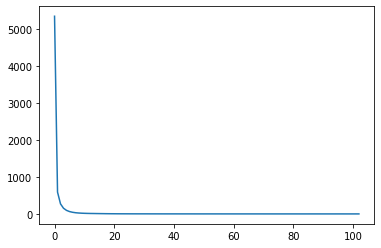

In [104]:
plt.plot(regressor.loss_curve_)

In [105]:
y_pred = regressor.predict(X_test)

In [106]:
np.sqrt(metrics.mean_squared_error(y_test,y_pred))

1.7132921291576166

In [107]:
y_test.stack().std()

35.98601232011795

In [109]:
y_test.stack().mean()

171.39827083333333

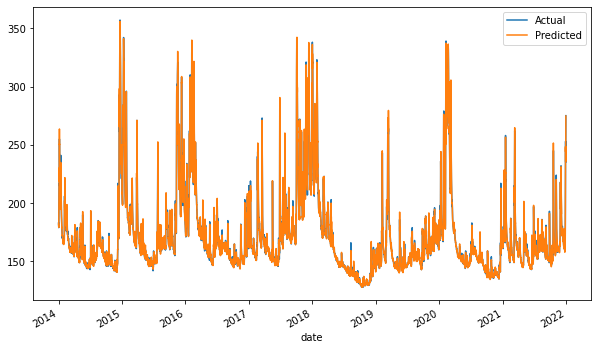

In [139]:
y_Pred = pd.DataFrame(y_pred, index=y_test.index)

df_temp = pd.DataFrame({'Actual': y_test[23], 'Predicted': y_Pred[23]})
df_temp = df_temp.sort_values(by="date")
df_temp.plot(figsize=(10,6))

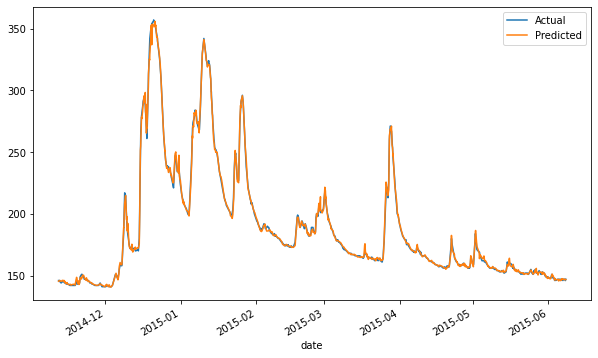

In [144]:
y_Pred = pd.DataFrame(y_pred, index=y_test.index)

df_temp = pd.DataFrame({'Actual': y_test[23], 'Predicted': y_Pred[23]})
df_temp = df_temp.sort_values(by="date")

df_temp.iloc[1500:2500].plot(figsize=(10,6))

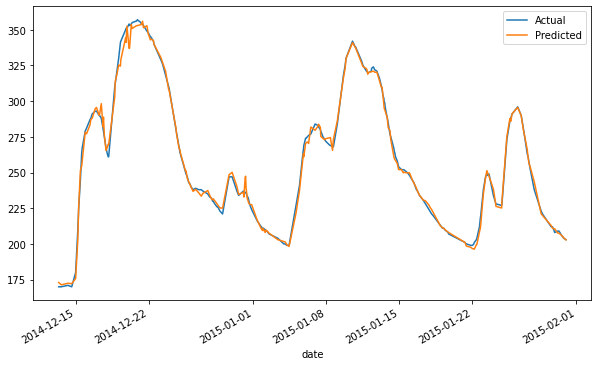

In [152]:
y_Pred = pd.DataFrame(y_pred, index=y_test.index)

df_temp = pd.DataFrame({'Actual': y_test[23], 'Predicted': y_Pred[23]})
df_temp = df_temp.sort_values(by="date")

df_temp.iloc[1650:1900].plot(figsize=(10,6))

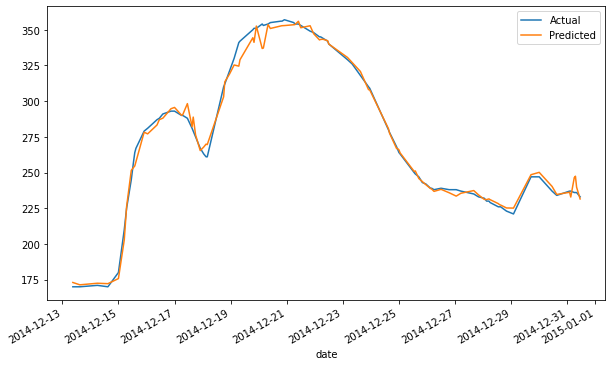

In [155]:
y_Pred = pd.DataFrame(y_pred, index=y_test.index)

df_temp = pd.DataFrame({'Actual': y_test[23], 'Predicted': y_Pred[23]})
df_temp = df_temp.sort_values(by="date")

df_temp.iloc[1650:1750].plot(figsize=(10,6))

In [128]:
df_max = df_temp
df_max['Difference'] = df_temp['Actual'] - df_temp['Predicted']

In [130]:
df_max.sort_values(by="Difference")

,Actual,Predicted,Difference
date,,,
2017-10-30 15:00:00,242.0,258.096933,-16.096933
2019-03-14 23:00:00,264.0,279.498813,-15.498813
2014-01-05 01:00:00,215.0,230.237524,-15.237524
2017-12-13 07:00:00,287.0,301.508023,-14.508023
2019-03-15 07:00:00,257.0,270.782676,-13.782676
...,...,...,...
2017-10-01 17:00:00,295.0,277.182567,17.817433
2016-06-13 20:00:00,189.0,170.014009,18.985991
2018-01-01 05:00:00,335.0,315.427530,19.572470
